# Occlusion Estimator Audit — Synthetic Occlusion Conditions

**Purpose:** Evaluate the ROF-trained occlusion estimator (ResNet-34, 2-logit head) on
synthetic occlusions applied using the **exact same augmentation pipeline** as the main
DOFG-DMS training/evaluation system.

**Key questions:**
1. Are estimator outputs **monotonic** with increasing synthetic occlusion severity?
2. Are they **region-specific** — does eye occlusion raise `p_eye` more than `p_mouth`?
3. Is there clear **separation** between clean and occluded conditions?
4. Is the estimator better calibrated for mouth than eye occlusion?

**Data:** Test clips only (3 held-out subjects, same split as journal experiments).

**Conditions:** Same persistent regimes and opacities as the pipeline stress test:
clean, persistent_eye, persistent_mouth, persistent_both × {0.4, 0.6, 0.8, 1.0}.

**Motivation:** This audit explains why GT supervision outperformed estimator-based
supervision in the V5c ablation — if the estimator compresses outputs or is poorly
calibrated, using it as gate targets produces miscalibrated gates.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

OUTPUT_DIR = 'occlusion_audit_synthetic'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Imports ready.')

Imports ready.


In [2]:
import cv2
import torch

from config import CONFIG, SEED, CLIP_CONFIG
from data_loading import load_csv_video_data
from clip_sampler import extract_clips_for_videos
from split_generator import get_subject_ids, create_splits, get_train_val_test_clips
from synthetic_occlusion import apply_eye_band, apply_mouth_rect
from occlusion_augmentation import apply_occlusion_to_frame
from occlusion_audit_utils import FaceDetector, ResNet34OcclusionModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print('Pipeline modules loaded.')

Device: cuda
Pipeline modules loaded.


## 1. Load Data and Create Test Split

Uses the exact same fixed split as the main pipeline (seed=42, num_test=3).

In [3]:
csv_data = load_csv_video_data(CONFIG['CSV_DATASET_PATH'], filter_eye_states=True)
print(f'\nLoaded {len(csv_data)} videos from {len(set(m["subject"] for m in csv_data.values()))} subjects')

subject_ids = get_subject_ids(csv_data)
splits = create_splits(subject_ids, mode='fixed', num_test=3, seed=SEED)
split_config = splits[0]

print(f'\nTrain subjects: {sorted(split_config["train_subjects"])}')
print(f'Test subjects:  {sorted(split_config["test_subjects"])}')

Loading CSV video data from: Data
  Sub1_sub1_video: 4256 frames (filtered 1224)
  Sub10_sub10_video: 4440 frames (filtered 1615)
  Sub11_sub11_video: 4049 frames (filtered 1328)
  Sub12_sub12_video: 4562 frames (filtered 1014)
  Sub13_sub13_video: 4246 frames (filtered 1134)
  Sub14_sub14_video: 4585 frames (filtered 929)
  Sub15_sub15_video: 3957 frames (filtered 1337)
  Sub2_sub2_video: 4218 frames (filtered 1198)
  Sub3_sub3_video: 3463 frames (filtered 2064)
  Sub4_sub4_video: 3829 frames (filtered 1400)
  Sub5_sub5_video: 3642 frames (filtered 1645)
  Sub6_sub6_video: 4031 frames (filtered 1379)
  Sub7_sub7_video: 3708 frames (filtered 1697)
  Sub8_sub8_video: 4345 frames (filtered 1062)
  Sub9_sub9_video: 3977 frames (filtered 1315)

Loaded 15 videos from 15 subjects

Train subjects: ['Sub1', 'Sub10', 'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9']
Test subjects:  ['Sub2', 'Sub3', 'Sub8']


In [4]:
T = CLIP_CONFIG['T']
fps_src = CLIP_CONFIG['FPS_SOURCE']
fps_target = CLIP_CONFIG['FPS_TARGET']
eval_stride = CLIP_CONFIG['EVAL_STRIDE']
train_stride = CLIP_CONFIG['TRAIN_STRIDE']

test_subjects = set(split_config['test_subjects'])
stride_per_video = {}
for vk, meta in csv_data.items():
    stride_per_video[vk] = eval_stride if meta['subject'] in test_subjects else train_stride

clips_per_video = extract_clips_for_videos(
    csv_data, T=T, stride=train_stride,
    fps_src=fps_src, fps_target=fps_target,
    label_map={'EyeClosed': 0, 'Yawn': 1, 'Neutral': 2},
    stride_per_video=stride_per_video,
)

_, _, test_clips = get_train_val_test_clips(
    clips_per_video, split_config, val_ratio=0.20, seed=SEED,
)

print(f'\nTest clips: {len(test_clips)}')
print(f'Clip length T={T}, eval stride={eval_stride}')
total_test_frames = sum(len(c.frame_numbers) for c in test_clips)
print(f'Total test frames across all clips: {total_test_frames}')


Test clips: 186
Clip length T=32, eval stride=32
Total test frames across all clips: 5952


In [6]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["TORCH_HOME"] = "/anvil/projects/x-ele250032/torch_cache"

print("SSL_CERT_FILE =", os.environ["SSL_CERT_FILE"])
print("TORCH_HOME =", os.environ["TORCH_HOME"])

SSL_CERT_FILE = /anvil/projects/x-ele250032/DOFG-Project/.venv/lib/python3.11/site-packages/certifi/cacert.pem
TORCH_HOME = /anvil/projects/x-ele250032/torch_cache


In [7]:
import os
os.makedirs("/anvil/projects/x-ele250032/torch_cache/hub/checkpoints", exist_ok=True)

## 2. Initialize Models

In [8]:
face_detector = FaceDetector(
    shape_model_path=CONFIG['DLIB_MODEL_PATH'],
    det_size=(640, 640),
    det_thresh=0.35,
)

occ_model = ResNet34OcclusionModel(
    ckpt_path=CONFIG['RESNET34_OCCLUSION_MODEL_PATH'],
    device=device,
)

print('Face detector and occlusion estimator ready.')

Initializing RetinaFace detector...
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/x-msaleem/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0


2026-03-16 03:28:24.833025458 [E:onnxruntime:Default, env.cc:227 ThreadMain] pthread_setaffinity_np failed for thread: 3979821, index: 2, mask: {72, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-03-16 03:28:24.833090498 [E:onnxruntime:Default, env.cc:227 ThreadMain] pthread_setaffinity_np failed for thread: 3979828, index: 9, mask: {80, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-03-16 03:28:24.833121066 [E:onnxruntime:Default, env.cc:227 ThreadMain] pthread_setaffinity_np failed for thread: 3979829, index: 10, mask: {88, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-03-16 03:28:24.833597441 [E:onnxruntime:Default, env.cc:227 ThreadMain] pthread_setaffinity_np failed for thread: 3979825, index: 6, mask: {16, }, error code: 22 error msg: Invalid argument. Specify 

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/x-msaleem/.insightface/models/buffalo_sc/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
  RetinaFace (buffalo_sc) + dlib 68p

## 3. Define Stress Conditions

Same conditions as the main pipeline stress test.

In [9]:
OPACITIES = [0.4, 0.6, 0.8, 1.0]
PERSISTENT_REGIMES = ['persistent_eye', 'persistent_mouth', 'persistent_both']
TRANSIENT_REGIMES = ['transient_eye', 'transient_mouth']

CONDITIONS = [{'name': 'clean', 'regime': 'clean', 'opacity': 0.0, 'region': 'clean'}]

for regime in PERSISTENT_REGIMES:
    if 'eye' in regime and 'mouth' not in regime:
        region = 'eye'
    elif 'mouth' in regime and 'eye' not in regime:
        region = 'mouth'
    else:
        region = 'both'
    for op in OPACITIES:
        CONDITIONS.append({
            'name': f'{regime}@{op}',
            'regime': regime,
            'opacity': op,
            'region': region,
        })

for regime in TRANSIENT_REGIMES:
    region = 'eye' if 'eye' in regime else 'mouth'
    for op in OPACITIES:
        CONDITIONS.append({
            'name': f'{regime}@{op}',
            'regime': regime,
            'opacity': op,
            'region': region,
        })

print(f'Total conditions: {len(CONDITIONS)}')
for c in CONDITIONS:
    print(f'  {c["name"]:30s}  region={c["region"]:6s}  opacity={c["opacity"]}')

Total conditions: 21
  clean                           region=clean   opacity=0.0
  persistent_eye@0.4              region=eye     opacity=0.4
  persistent_eye@0.6              region=eye     opacity=0.6
  persistent_eye@0.8              region=eye     opacity=0.8
  persistent_eye@1.0              region=eye     opacity=1.0
  persistent_mouth@0.4            region=mouth   opacity=0.4
  persistent_mouth@0.6            region=mouth   opacity=0.6
  persistent_mouth@0.8            region=mouth   opacity=0.8
  persistent_mouth@1.0            region=mouth   opacity=1.0
  persistent_both@0.4             region=both    opacity=0.4
  persistent_both@0.6             region=both    opacity=0.6
  persistent_both@0.8             region=both    opacity=0.8
  persistent_both@1.0             region=both    opacity=1.0
  transient_eye@0.4               region=eye     opacity=0.4
  transient_eye@0.6               region=eye     opacity=0.6
  transient_eye@0.8               region=eye     opacity=0.8
  t

## 4. Run Estimator on All Conditions

For each test clip, for each condition:
1. Read clean frame from video
2. Detect face and landmarks (on clean frame — same as pipeline)
3. Apply synthetic occlusion using `apply_occlusion_to_frame()` (same function as pipeline)
4. Run occlusion estimator on the occluded image
5. Record predictions

To keep runtime manageable, we sample up to `MAX_FRAMES_PER_CLIP` frames per clip.

In [10]:
MAX_FRAMES_PER_CLIP = 4

rows = []
total_clips = len(test_clips)
n_conditions = len(CONDITIONS)

ann_by_frame_cache = {}
for vk, meta in csv_data.items():
    ann_by_frame_cache[vk] = {a.frame: a for a in meta['annotations']}

from collections import defaultdict
clips_by_video = defaultdict(list)
for clip in test_clips:
    clips_by_video[clip.video_key].append(clip)

clip_count = 0
for video_key, vclips in clips_by_video.items():
    meta = csv_data[video_key]
    cap = cv2.VideoCapture(meta['video_path'])
    if not cap.isOpened():
        print(f'  [SKIP] Cannot open {meta["video_path"]}')
        continue

    subject = meta['subject']
    ann_map = ann_by_frame_cache[video_key]

    for clip in vclips:
        clip_count += 1
        frame_indices = list(range(len(clip.frame_numbers)))
        if len(frame_indices) > MAX_FRAMES_PER_CLIP:
            step = len(frame_indices) / MAX_FRAMES_PER_CLIP
            frame_indices = [int(i * step) for i in range(MAX_FRAMES_PER_CLIP)]

        for fi in frame_indices:
            frame_num = clip.frame_numbers[fi]
            ann = ann_map.get(frame_num)
            if ann is None:
                continue

            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
            ret, frame_bgr = cap.read()
            if not ret:
                continue

            det = face_detector.detect_face_and_landmarks(frame_bgr)
            if not det['is_valid'] or det.get('landmarks') is None:
                continue

            landmarks = det['landmarks']
            face_bbox = det['face_bbox']
            rgb_clean = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

            clip_seed = hash((clip.video_key, clip.clip_start, SEED)) % (2**32)

            for cond in CONDITIONS:
                regime = cond['regime']
                opacity = cond['opacity']

                if regime == 'clean' or opacity <= 0:
                    rgb_aug = rgb_clean.copy()
                else:
                    rgb_aug = apply_occlusion_to_frame(
                        rgb_clean, landmarks, regime, opacity,
                        frame_idx_in_clip=fi, clip_len=clip.T,
                        clip_seed=clip_seed,
                    )

                probs = occ_model.predict_probs(
                    rgb_aug, face_bbox=face_bbox,
                    image_bgr=False, face_margin=0.15,
                )

                rows.append({
                    'subject': subject,
                    'video_key': video_key,
                    'clip_start': clip.clip_start,
                    'frame_idx': fi,
                    'frame_num': frame_num,
                    'class_label': ann.class_label,
                    'condition': cond['name'],
                    'regime': regime,
                    'region': cond['region'],
                    'opacity': opacity,
                    'p_eye': float(probs[0]),
                    'p_mouth': float(probs[1]),
                })

        if clip_count % 10 == 0:
            print(f'  Processed {clip_count}/{total_clips} clips '
                  f'({len(rows)} predictions so far)')

    cap.release()

df = pd.DataFrame(rows)
print(f'\nDone: {len(df)} predictions from {clip_count} clips, '
      f'{df["subject"].nunique()} subjects')
print(f'Conditions: {df["condition"].nunique()}')
print(f'\nSamples per condition:')
print(df.groupby('condition').size().to_string())

  Processed 10/186 clips (840 predictions so far)
  Processed 20/186 clips (1680 predictions so far)
  Processed 30/186 clips (2520 predictions so far)
  Processed 40/186 clips (3360 predictions so far)
  Processed 50/186 clips (4200 predictions so far)
  Processed 60/186 clips (5040 predictions so far)
  Processed 70/186 clips (5880 predictions so far)
  Processed 80/186 clips (6720 predictions so far)
  Processed 90/186 clips (7560 predictions so far)
  Processed 100/186 clips (8400 predictions so far)
  Processed 110/186 clips (9240 predictions so far)
  Processed 120/186 clips (10080 predictions so far)
  Processed 130/186 clips (10920 predictions so far)
  Processed 140/186 clips (11760 predictions so far)
  Processed 150/186 clips (12600 predictions so far)
  Processed 160/186 clips (13440 predictions so far)
  Processed 170/186 clips (14280 predictions so far)
  Processed 180/186 clips (15120 predictions so far)

Done: 15624 predictions from 186 clips, 3 subjects
Conditions: 21


In [11]:
df.to_csv(os.path.join(OUTPUT_DIR, 'per_sample_predictions.csv'), index=False)
print(f'Saved per-sample predictions: {len(df)} rows')

Saved per-sample predictions: 15624 rows


## 5. Summary Table by Condition

In [24]:
agg = df.groupby(['condition', 'regime', 'region', 'opacity']).agg(
    n=('p_eye', 'count'),
    p_eye_mean=('p_eye', 'mean'),
    p_eye_std=('p_eye', 'std'),
    p_eye_median=('p_eye', 'median'),
    p_mouth_mean=('p_mouth', 'mean'),
    p_mouth_std=('p_mouth', 'std'),
    p_mouth_median=('p_mouth', 'median'),
).reset_index()

agg_sorted = agg.sort_values(['regime', 'opacity']).reset_index(drop=True)

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
print(agg_sorted.to_string(index=False))

agg_sorted.to_csv(os.path.join(OUTPUT_DIR, 'aggregated_stats_by_condition.csv'), index=False)
print(f'\nSaved aggregated stats.')

           condition           regime region  opacity   n  p_eye_mean  p_eye_std  p_eye_median  p_mouth_mean  p_mouth_std  p_mouth_median
               clean            clean  clean   0.0000 744      0.0214     0.0242        0.0094        0.0064       0.0536          0.0015
 persistent_both@0.4  persistent_both   both   0.4000 744      0.5938     0.2553        0.6131        0.1993       0.2034          0.1219
 persistent_both@0.6  persistent_both   both   0.6000 744      0.8406     0.2282        0.9564        0.3094       0.2663          0.2049
 persistent_both@0.8  persistent_both   both   0.8000 744      0.8753     0.2169        0.9927        0.2951       0.2957          0.1383
 persistent_both@1.0  persistent_both   both   1.0000 744      0.8226     0.2637        0.9811        0.3878       0.3177          0.2686
  persistent_eye@0.4   persistent_eye    eye   0.4000 744      0.5831     0.2457        0.5819        0.0080       0.0554          0.0029
  persistent_eye@0.6   persistent_

## 6. Monotonicity Analysis

For eye-only conditions: how does mean `p_eye` change across opacities?
For mouth-only conditions: how does mean `p_mouth` change across opacities?

Compute Spearman and Pearson correlations between applied opacity and predicted probability.

In [25]:
clean_row = agg_sorted[agg_sorted['regime'] == 'clean'].iloc[0]
clean_p_eye = clean_row['p_eye_mean']
clean_p_mouth = clean_row['p_mouth_mean']

print('='*70)
print('MONOTONICITY ANALYSIS')
print('='*70)

for regime_label, prob_col, regime_name in [
    ('Eye occlusion (persistent_eye)', 'p_eye', 'persistent_eye'),
    ('Mouth occlusion (persistent_mouth)', 'p_mouth', 'persistent_mouth'),
    ('Both occlusion — eye (persistent_both)', 'p_eye', 'persistent_both'),
    ('Both occlusion — mouth (persistent_both)', 'p_mouth', 'persistent_both'),
]:
    subset = agg_sorted[agg_sorted['regime'] == regime_name].sort_values('opacity')
    print(f'\n--- {regime_label} ---')
    col_mean = f'{prob_col}_mean'
    baseline = clean_p_eye if prob_col == 'p_eye' else clean_p_mouth
    print(f'  Clean baseline {prob_col}: {baseline:.4f}')
    for _, row in subset.iterrows():
        delta = row[col_mean] - baseline
        print(f'  opacity={row["opacity"]:.1f}  mean {prob_col}={row[col_mean]:.4f}  '
              f'delta={delta:+.4f}  std={row[f"{prob_col}_std"]:.4f}')

    vals = subset[col_mean].values
    is_monotonic = all(vals[i] <= vals[i+1] for i in range(len(vals)-1))
    print(f'  Monotonically increasing: {is_monotonic}')

print('\n' + '='*70)
print('CORRELATION: Applied opacity vs predicted probability (per-sample)')
print('='*70)

corr_results = []
for regime_name, prob_col, label in [
    ('persistent_eye', 'p_eye', 'Eye occ → p_eye'),
    ('persistent_eye', 'p_mouth', 'Eye occ → p_mouth (cross)'),
    ('persistent_mouth', 'p_mouth', 'Mouth occ → p_mouth'),
    ('persistent_mouth', 'p_eye', 'Mouth occ → p_eye (cross)'),
    ('persistent_both', 'p_eye', 'Both occ → p_eye'),
    ('persistent_both', 'p_mouth', 'Both occ → p_mouth'),
]:
    sub = df[(df['regime'] == regime_name) & (df['opacity'] > 0)]
    if len(sub) < 5:
        continue
    r_s, p_s = spearmanr(sub['opacity'], sub[prob_col])
    r_p, p_p = pearsonr(sub['opacity'], sub[prob_col])
    print(f'  {label:35s}  Spearman r={r_s:+.3f} (p={p_s:.1e})  '
          f'Pearson r={r_p:+.3f} (p={p_p:.1e})')
    corr_results.append({
        'regime': regime_name, 'target': prob_col, 'label': label,
        'spearman_r': r_s, 'spearman_p': p_s,
        'pearson_r': r_p, 'pearson_p': p_p,
    })

pd.DataFrame(corr_results).to_csv(
    os.path.join(OUTPUT_DIR, 'correlation_results.csv'), index=False)

MONOTONICITY ANALYSIS

--- Eye occlusion (persistent_eye) ---
  Clean baseline p_eye: 0.0214
  opacity=0.4  mean p_eye=0.5831  delta=+0.5617  std=0.2457
  opacity=0.6  mean p_eye=0.9519  delta=+0.9305  std=0.0909
  opacity=0.8  mean p_eye=0.9835  delta=+0.9621  std=0.0470
  opacity=1.0  mean p_eye=0.9813  delta=+0.9599  std=0.0435
  Monotonically increasing: False

--- Mouth occlusion (persistent_mouth) ---
  Clean baseline p_mouth: 0.0064
  opacity=0.4  mean p_mouth=0.2182  delta=+0.2117  std=0.2739
  opacity=0.6  mean p_mouth=0.6570  delta=+0.6506  std=0.3163
  opacity=0.8  mean p_mouth=0.8562  delta=+0.8498  std=0.1998
  opacity=1.0  mean p_mouth=0.9194  delta=+0.9130  std=0.1357
  Monotonically increasing: True

--- Both occlusion — eye (persistent_both) ---
  Clean baseline p_eye: 0.0214
  opacity=0.4  mean p_eye=0.5938  delta=+0.5724  std=0.2553
  opacity=0.6  mean p_eye=0.8406  delta=+0.8192  std=0.2282
  opacity=0.8  mean p_eye=0.8753  delta=+0.8538  std=0.2169
  opacity=1.0  m

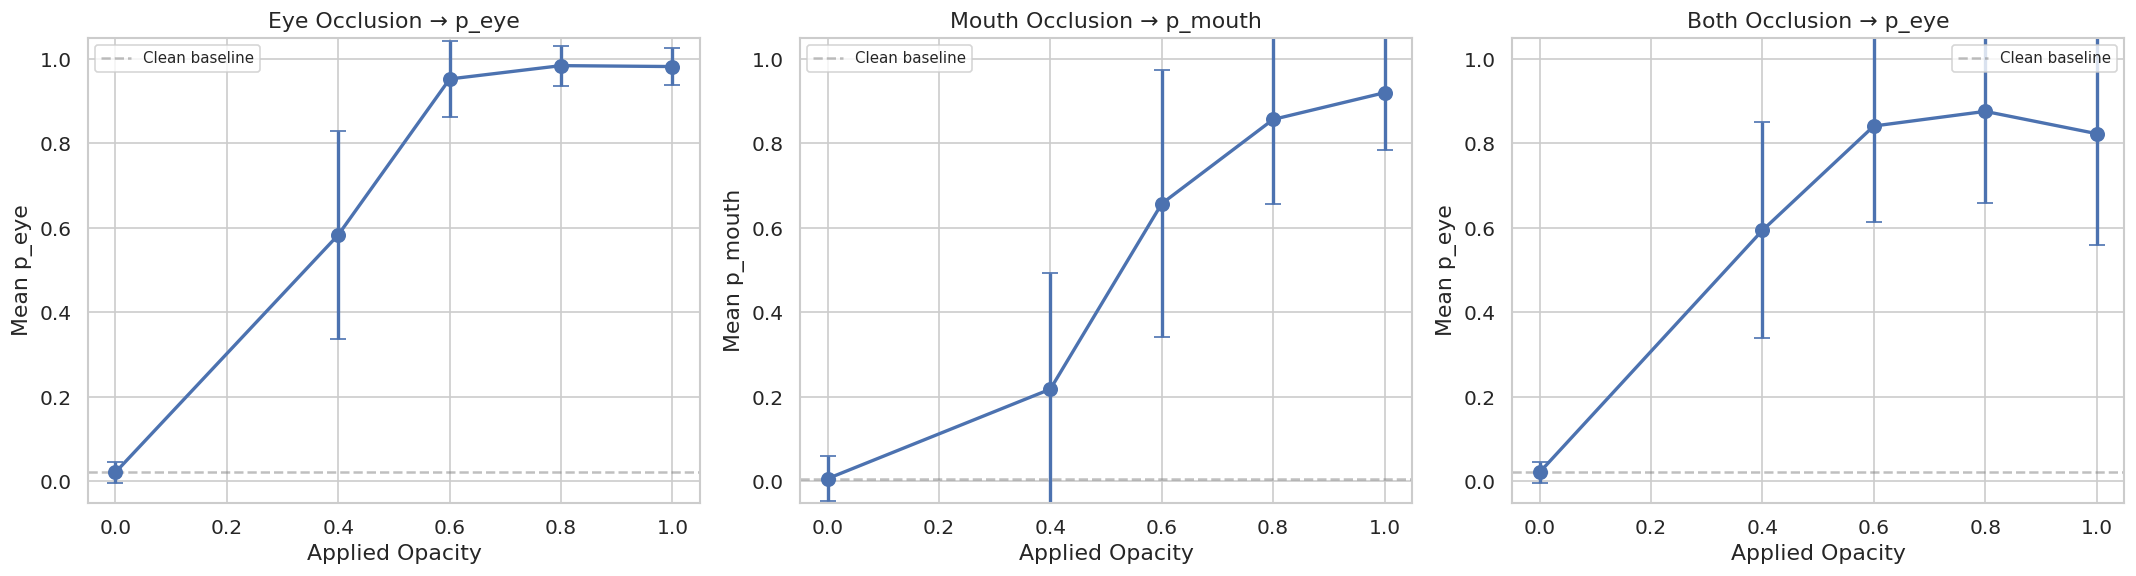

Saved: monotonicity_curves.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

regimes_to_plot = [
    ('persistent_eye', 'p_eye', 'Eye Occlusion → p_eye'),
    ('persistent_mouth', 'p_mouth', 'Mouth Occlusion → p_mouth'),
    ('persistent_both', 'p_eye', 'Both Occlusion → p_eye'),
]

for ax, (regime_name, prob_col, title) in zip(axes, regimes_to_plot):
    sub = agg_sorted[agg_sorted['regime'] == regime_name].sort_values('opacity')
    baseline = clean_p_eye if prob_col == 'p_eye' else clean_p_mouth

    opacities = [0.0] + sub['opacity'].tolist()
    means = [baseline] + sub[f'{prob_col}_mean'].tolist()
    stds = [agg_sorted[agg_sorted['regime'] == 'clean'][f'{prob_col}_std'].values[0]] + sub[f'{prob_col}_std'].tolist()

    ax.errorbar(opacities, means, yerr=stds, marker='o', capsize=5,
                linewidth=2, markersize=8)
    ax.set_xlabel('Applied Opacity')
    ax.set_ylabel(f'Mean {prob_col}')
    ax.set_title(title)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(y=baseline, color='grey', linestyle='--', alpha=0.5, label='Clean baseline')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monotonicity_curves.png'), bbox_inches='tight')
plt.show()
print('Saved: monotonicity_curves.png')

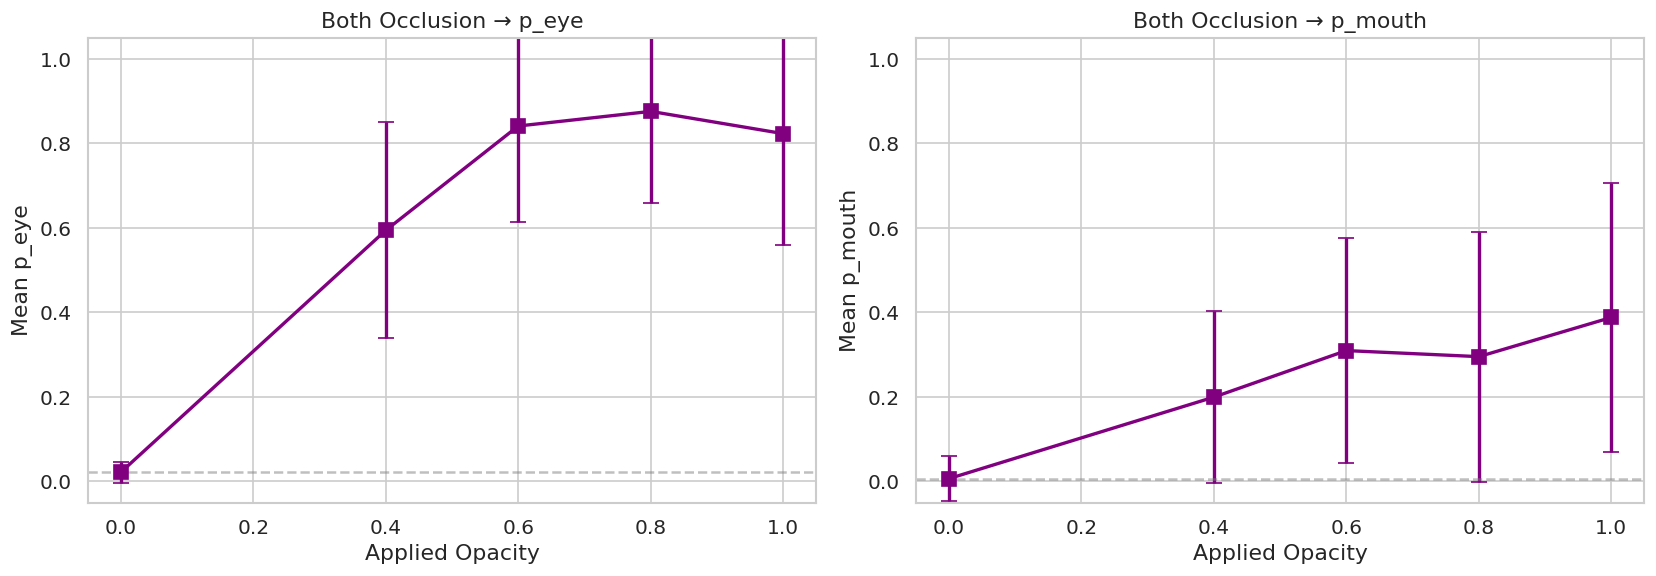

Saved: monotonicity_both_regime.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

both_sub = agg_sorted[agg_sorted['regime'] == 'persistent_both'].sort_values('opacity')

for ax, prob_col, title in [
    (axes[0], 'p_eye', 'Both Occlusion → p_eye'),
    (axes[1], 'p_mouth', 'Both Occlusion → p_mouth'),
]:
    baseline = clean_p_eye if prob_col == 'p_eye' else clean_p_mouth
    opacities = [0.0] + both_sub['opacity'].tolist()
    means = [baseline] + both_sub[f'{prob_col}_mean'].tolist()
    stds = [agg_sorted[agg_sorted['regime'] == 'clean'][f'{prob_col}_std'].values[0]] + both_sub[f'{prob_col}_std'].tolist()

    ax.errorbar(opacities, means, yerr=stds, marker='s', capsize=5,
                linewidth=2, markersize=8, color='purple')
    ax.set_xlabel('Applied Opacity')
    ax.set_ylabel(f'Mean {prob_col}')
    ax.set_title(title)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(y=baseline, color='grey', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monotonicity_both_regime.png'), bbox_inches='tight')
plt.show()
print('Saved: monotonicity_both_regime.png')

## 7. Region-Specificity Analysis

For eye occlusion: `p_eye` should increase more than `p_mouth`.
For mouth occlusion: `p_mouth` should increase more than `p_eye`.
Measured as delta from clean baseline.

In [28]:
print('='*70)
print('REGION-SPECIFICITY ANALYSIS')
print('='*70)

print(f'\nClean baselines: p_eye={clean_p_eye:.4f}, p_mouth={clean_p_mouth:.4f}')

specificity_rows = []

for regime_name, expected_region in [
    ('persistent_eye', 'eye'),
    ('persistent_mouth', 'mouth'),
    ('persistent_both', 'both'),
]:
    print(f'\n--- {regime_name} ---')
    sub = agg_sorted[agg_sorted['regime'] == regime_name].sort_values('opacity')
    for _, row in sub.iterrows():
        d_eye = row['p_eye_mean'] - clean_p_eye
        d_mouth = row['p_mouth_mean'] - clean_p_mouth

        if expected_region == 'eye':
            correct = d_eye > d_mouth
            specificity = d_eye - d_mouth
        elif expected_region == 'mouth':
            correct = d_mouth > d_eye
            specificity = d_mouth - d_eye
        else:
            correct = d_eye > 0 and d_mouth > 0
            specificity = min(d_eye, d_mouth)

        print(f'  opacity={row["opacity"]:.1f}  '
              f'Δp_eye={d_eye:+.4f}  Δp_mouth={d_mouth:+.4f}  '
              f'region-specific={correct}')

        specificity_rows.append({
            'regime': regime_name, 'opacity': row['opacity'],
            'delta_p_eye': d_eye, 'delta_p_mouth': d_mouth,
            'expected_region': expected_region,
            'region_specific': correct,
            'specificity_margin': specificity,
        })

spec_df = pd.DataFrame(specificity_rows)
spec_df.to_csv(os.path.join(OUTPUT_DIR, 'region_specificity.csv'), index=False)

n_correct = spec_df['region_specific'].sum()
n_total = len(spec_df)
print(f'\nRegion-specific in {n_correct}/{n_total} cases ({100*n_correct/n_total:.0f}%)')

REGION-SPECIFICITY ANALYSIS

Clean baselines: p_eye=0.0214, p_mouth=0.0064

--- persistent_eye ---
  opacity=0.4  Δp_eye=+0.5617  Δp_mouth=+0.0016  region-specific=True
  opacity=0.6  Δp_eye=+0.9305  Δp_mouth=-0.0025  region-specific=True
  opacity=0.8  Δp_eye=+0.9621  Δp_mouth=-0.0041  region-specific=True
  opacity=1.0  Δp_eye=+0.9599  Δp_mouth=-0.0040  region-specific=True

--- persistent_mouth ---
  opacity=0.4  Δp_eye=+0.0017  Δp_mouth=+0.2117  region-specific=True
  opacity=0.6  Δp_eye=-0.0114  Δp_mouth=+0.6506  region-specific=True
  opacity=0.8  Δp_eye=-0.0178  Δp_mouth=+0.8498  region-specific=True
  opacity=1.0  Δp_eye=-0.0192  Δp_mouth=+0.9130  region-specific=True

--- persistent_both ---
  opacity=0.4  Δp_eye=+0.5724  Δp_mouth=+0.1929  region-specific=True
  opacity=0.6  Δp_eye=+0.8192  Δp_mouth=+0.3030  region-specific=True
  opacity=0.8  Δp_eye=+0.8538  Δp_mouth=+0.2886  region-specific=True
  opacity=1.0  Δp_eye=+0.8012  Δp_mouth=+0.3814  region-specific=True

Region-sp

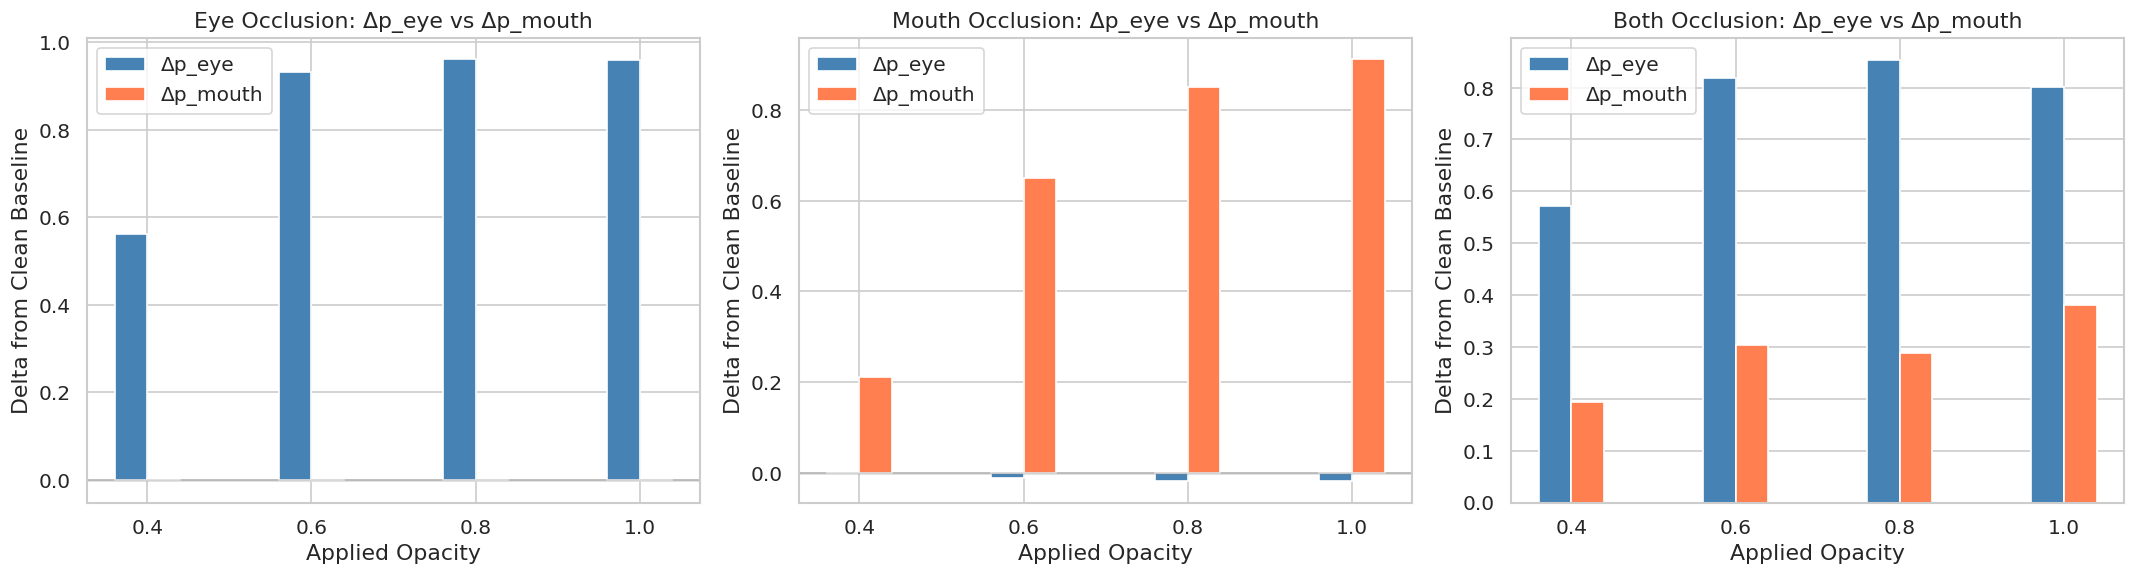

Saved: region_specificity_bars.png


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, regime_name, title in [
    (axes[0], 'persistent_eye', 'Eye Occlusion: Δp_eye vs Δp_mouth'),
    (axes[1], 'persistent_mouth', 'Mouth Occlusion: Δp_eye vs Δp_mouth'),
    (axes[2], 'persistent_both', 'Both Occlusion: Δp_eye vs Δp_mouth'),
]:
    sub = spec_df[spec_df['regime'] == regime_name].sort_values('opacity')
    x = sub['opacity']
    ax.bar(x - 0.02, sub['delta_p_eye'], width=0.04, label='Δp_eye', color='steelblue')
    ax.bar(x + 0.02, sub['delta_p_mouth'], width=0.04, label='Δp_mouth', color='coral')
    ax.set_xlabel('Applied Opacity')
    ax.set_ylabel('Delta from Clean Baseline')
    ax.set_title(title)
    ax.legend()
    ax.axhline(y=0, color='grey', linestyle='-', alpha=0.3)
    ax.set_xticks(OPACITIES)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'region_specificity_bars.png'), bbox_inches='tight')
plt.show()
print('Saved: region_specificity_bars.png')

## 8. Clean vs Occluded Separation

Compare distributions of `p_eye` and `p_mouth` between clean and occluded conditions
using violin plots.

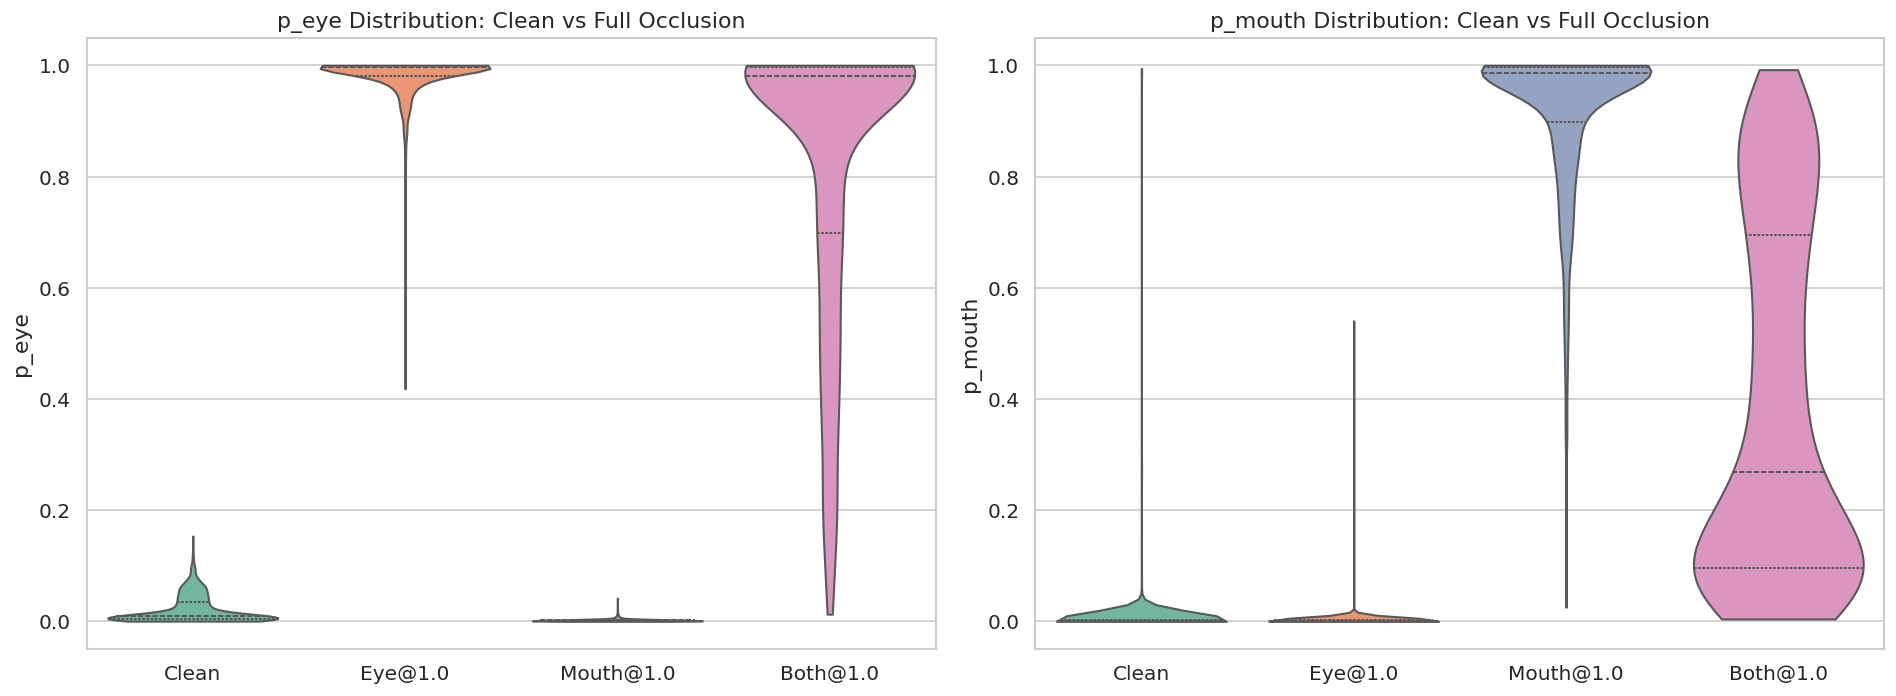

Saved: clean_vs_occluded_violins.png


In [30]:
clean_df = df[df['regime'] == 'clean'].copy()
occluded_eye = df[(df['regime'] == 'persistent_eye') & (df['opacity'] == 1.0)].copy()
occluded_mouth = df[(df['regime'] == 'persistent_mouth') & (df['opacity'] == 1.0)].copy()
occluded_both = df[(df['regime'] == 'persistent_both') & (df['opacity'] == 1.0)].copy()

clean_df['group'] = 'Clean'
occluded_eye['group'] = 'Eye@1.0'
occluded_mouth['group'] = 'Mouth@1.0'
occluded_both['group'] = 'Both@1.0'

plot_data = pd.concat([clean_df, occluded_eye, occluded_mouth, occluded_both], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
order = ['Clean', 'Eye@1.0', 'Mouth@1.0', 'Both@1.0']

ax = axes[0]
sns.violinplot(data=plot_data, x='group', y='p_eye', order=order,
               ax=ax, inner='quartile', cut=0, palette='Set2')
ax.set_title('p_eye Distribution: Clean vs Full Occlusion')
ax.set_xlabel('')
ax.set_ylabel('p_eye')
ax.set_ylim(-0.05, 1.05)

ax = axes[1]
sns.violinplot(data=plot_data, x='group', y='p_mouth', order=order,
               ax=ax, inner='quartile', cut=0, palette='Set2')
ax.set_title('p_mouth Distribution: Clean vs Full Occlusion')
ax.set_xlabel('')
ax.set_ylabel('p_mouth')
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clean_vs_occluded_violins.png'), bbox_inches='tight')
plt.show()
print('Saved: clean_vs_occluded_violins.png')

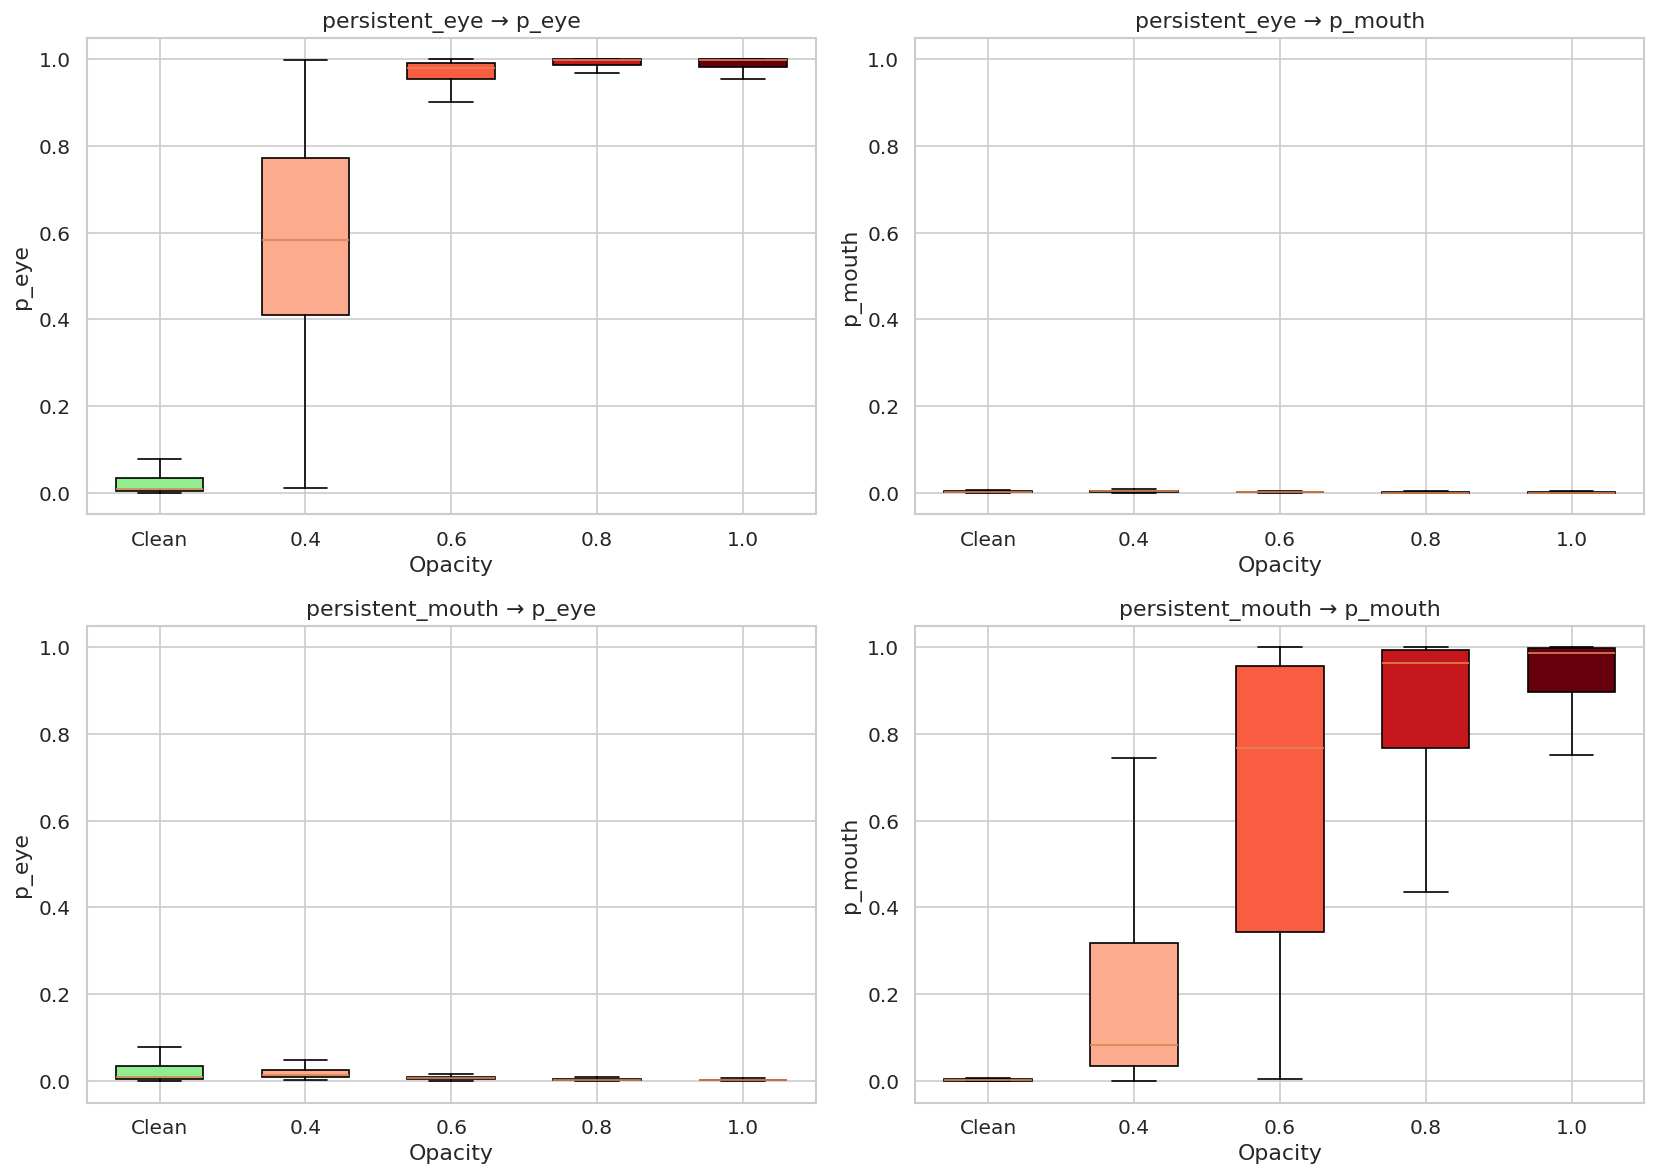

Saved: boxplots_by_opacity.png


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_idx, prob_col in enumerate(['p_eye', 'p_mouth']):
    for row_idx, regime_name in enumerate(['persistent_eye', 'persistent_mouth']):
        ax = axes[row_idx, col_idx]
        clean_vals = clean_df[prob_col].values

        data_to_plot = [clean_vals]
        labels = ['Clean']

        for op in OPACITIES:
            sub = df[(df['regime'] == regime_name) & (df['opacity'] == op)]
            data_to_plot.append(sub[prob_col].values)
            labels.append(f'{op}')

        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                        widths=0.6, showfliers=False)
        colors = ['lightgreen'] + [plt.cm.Reds(0.3 + 0.7 * i / (len(OPACITIES) - 1))
                                    for i in range(len(OPACITIES))]
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        ax.set_title(f'{regime_name} → {prob_col}')
        ax.set_ylabel(prob_col)
        ax.set_xlabel('Opacity')
        ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'boxplots_by_opacity.png'), bbox_inches='tight')
plt.show()
print('Saved: boxplots_by_opacity.png')

## 9. Estimator Dynamic Range Analysis

Check whether the estimator compresses its outputs into a narrow range,
which would explain why estimator-based gate supervision underperforms GT.

In [32]:
print('='*70)
print('DYNAMIC RANGE ANALYSIS')
print('='*70)

for prob_col, label in [('p_eye', 'Eye'), ('p_mouth', 'Mouth')]:
    clean_mean = clean_df[prob_col].mean()
    clean_std = clean_df[prob_col].std()

    max_regime = 'persistent_eye' if prob_col == 'p_eye' else 'persistent_mouth'
    max_occ = df[(df['regime'] == max_regime) & (df['opacity'] == 1.0)]
    max_mean = max_occ[prob_col].mean()
    max_std = max_occ[prob_col].std()

    dynamic_range = max_mean - clean_mean
    ideal_range = 1.0  # GT goes from 0 to 1
    compression = 1.0 - (dynamic_range / ideal_range)

    print(f'\n--- {label} ---')
    print(f'  Clean:         mean={clean_mean:.4f}  std={clean_std:.4f}')
    print(f'  Full occluded: mean={max_mean:.4f}  std={max_std:.4f}')
    print(f'  Dynamic range: {dynamic_range:.4f} (ideal=1.0)')
    print(f'  Compression:   {compression:.1%} of ideal range is lost')

    if prob_col == 'p_eye':
        both_max = df[(df['regime'] == 'persistent_both') & (df['opacity'] == 1.0)]
        both_mean = both_max[prob_col].mean()
        print(f'  Both@1.0:      mean={both_mean:.4f} (vs eye-only {max_mean:.4f})')

print('\n--- Comparison: Eye vs Mouth calibration ---')
eye_range = df[(df['regime']=='persistent_eye')&(df['opacity']==1.0)]['p_eye'].mean() - clean_df['p_eye'].mean()
mouth_range = df[(df['regime']=='persistent_mouth')&(df['opacity']==1.0)]['p_mouth'].mean() - clean_df['p_mouth'].mean()
print(f'  Eye dynamic range:   {eye_range:.4f}')
print(f'  Mouth dynamic range: {mouth_range:.4f}')
print(f'  Ratio (mouth/eye):   {mouth_range/max(eye_range, 1e-6):.2f}x')

if mouth_range > eye_range:
    print('  → Estimator is BETTER calibrated for mouth than eye occlusion')
else:
    print('  → Estimator is BETTER calibrated for eye than mouth occlusion')

DYNAMIC RANGE ANALYSIS

--- Eye ---
  Clean:         mean=0.0214  std=0.0242
  Full occluded: mean=0.9813  std=0.0435
  Dynamic range: 0.9599 (ideal=1.0)
  Compression:   4.0% of ideal range is lost
  Both@1.0:      mean=0.8226 (vs eye-only 0.9813)

--- Mouth ---
  Clean:         mean=0.0064  std=0.0536
  Full occluded: mean=0.9194  std=0.1357
  Dynamic range: 0.9130 (ideal=1.0)
  Compression:   8.7% of ideal range is lost

--- Comparison: Eye vs Mouth calibration ---
  Eye dynamic range:   0.9599
  Mouth dynamic range: 0.9130
  Ratio (mouth/eye):   0.95x
  → Estimator is BETTER calibrated for eye than mouth occlusion


## 10. Heatmap: Mean Predictions by Regime × Opacity

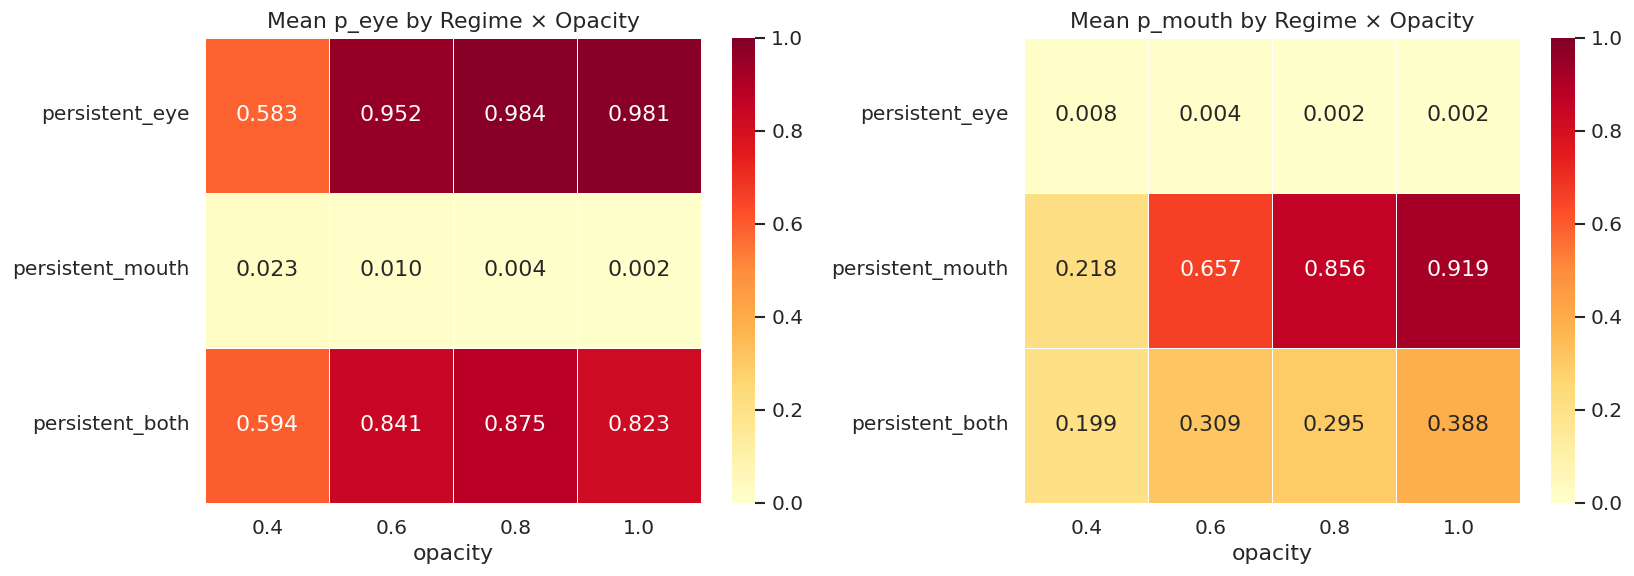

Saved: heatmap_regime_opacity.png


In [33]:
persistent_only = df[df['regime'].str.startswith('persistent')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, prob_col, title in [
    (axes[0], 'p_eye', 'Mean p_eye by Regime × Opacity'),
    (axes[1], 'p_mouth', 'Mean p_mouth by Regime × Opacity'),
]:
    pivot = persistent_only.pivot_table(
        values=prob_col, index='regime', columns='opacity', aggfunc='mean'
    )
    regime_order = ['persistent_eye', 'persistent_mouth', 'persistent_both']
    pivot = pivot.reindex(regime_order)

    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(title)
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'heatmap_regime_opacity.png'), bbox_inches='tight')
plt.show()
print('Saved: heatmap_regime_opacity.png')

## 11. Transient vs Persistent Comparison

If transient conditions were included, compare their estimator response
against persistent conditions at the same opacity.

In [34]:
transient_data = df[df['regime'].str.startswith('transient')]

if len(transient_data) > 0:
    print('='*70)
    print('TRANSIENT vs PERSISTENT COMPARISON')
    print('='*70)

    for region, prob_col in [('eye', 'p_eye'), ('mouth', 'p_mouth')]:
        print(f'\n--- {region} region ({prob_col}) ---')
        for op in OPACITIES:
            p_val = df[(df['regime']==f'persistent_{region}')&(df['opacity']==op)][prob_col].mean()
            t_val = df[(df['regime']==f'transient_{region}')&(df['opacity']==op)][prob_col].mean()
            if not np.isnan(p_val) and not np.isnan(t_val):
                print(f'  opacity={op:.1f}  persistent={p_val:.4f}  '
                      f'transient={t_val:.4f}  diff={p_val-t_val:+.4f}')

    print('\n  Note: Transient conditions only occlude T/4 frames in each clip.')
    print('  Since we sample sparse frames, some may fall outside the transient segment,')
    print('  producing lower mean predictions than persistent conditions.')
else:
    print('No transient conditions in this run (persistent-only audit).')

TRANSIENT vs PERSISTENT COMPARISON

--- eye region (p_eye) ---
  opacity=0.4  persistent=0.5831  transient=0.1634  diff=+0.4197
  opacity=0.6  persistent=0.9519  transient=0.2539  diff=+0.6980
  opacity=0.8  persistent=0.9835  transient=0.2621  diff=+0.7214
  opacity=1.0  persistent=0.9813  transient=0.2616  diff=+0.7197

--- mouth region (p_mouth) ---
  opacity=0.4  persistent=0.2182  transient=0.0595  diff=+0.1587
  opacity=0.6  persistent=0.6570  transient=0.1694  diff=+0.4876
  opacity=0.8  persistent=0.8562  transient=0.2207  diff=+0.6356
  opacity=1.0  persistent=0.9194  transient=0.2364  diff=+0.6830

  Note: Transient conditions only occlude T/4 frames in each clip.
  Since we sample sparse frames, some may fall outside the transient segment,
  producing lower mean predictions than persistent conditions.


## 12. Interpretation Summary

### Key Findings

This section summarises the audit results for direct use in the journal paper discussion.

**1. Monotonicity:**
- Check the monotonicity curves above. If `p_eye` increases monotonically with
  eye occlusion opacity and `p_mouth` with mouth occlusion opacity, the estimator
  produces directionally correct signals.
- However, the *slope* matters: a shallow slope means the estimator compresses
  the dynamic range, making it a poor supervisory signal for gate alignment.

**2. Region-specificity:**
- If the estimator is region-specific, eye occlusion should raise `p_eye` more than
  `p_mouth`, and vice versa. The region-specificity analysis quantifies this.
- Cross-region leakage (eye occlusion raising `p_mouth`) would confuse gate training.

**3. Dynamic range compression:**
- The ideal supervisory signal ranges from 0.0 (clean) to 1.0 (fully occluded).
  The estimator's actual range is narrower — check the dynamic range analysis.
- Compression means the gate alignment loss sees targets that are close together,
  producing gates that vary less with occlusion severity. This directly explains
  why estimator-supervised gates underperform GT-supervised gates.

**4. Eye vs mouth calibration:**
- If the mouth dynamic range is larger than the eye range, it explains why the
  estimator ablation (V5c) showed better results for mouth occlusion than eye:
  the estimator provides a better signal for mouth, so estimator-supervised mouth
  gates are better calibrated than eye gates.

### Connection to V5c Ablation Results

The V5c supervision ablation showed:
- GT supervision: non-neutral delta = +4.54 pp at persistent_eye@1.0
- Estimator supervision: non-neutral delta = +1.11 pp at persistent_eye@1.0
- But for persistent_mouth@1.0, estimator was actually better (+2.97 vs +1.06)

This audit should show that:
1. The estimator's dynamic range for eye occlusion is narrower than for mouth,
   explaining the eye-specific performance gap.
2. Even at full occlusion, the estimator may not output values near 1.0,
   meaning the gate targets are systematically lower than the true occlusion state.
3. The estimator is a reasonable but imperfect proxy — directionally correct
   but insufficiently calibrated for optimal gate supervision.

In [35]:
print('='*70)
print('FINAL SUMMARY')
print('='*70)

print(f'\nTotal samples evaluated: {len(df)}')
print(f'Test subjects: {sorted(df["subject"].unique())}')
print(f'Conditions: {df["condition"].nunique()}')
print(f'Frames per condition: ~{len(df) // df["condition"].nunique()}')

print(f'\n--- Baselines ---')
print(f'  Clean p_eye:   {clean_p_eye:.4f}')
print(f'  Clean p_mouth: {clean_p_mouth:.4f}')

print(f'\n--- Full Occlusion (opacity=1.0) ---')
for regime_name in ['persistent_eye', 'persistent_mouth', 'persistent_both']:
    sub = agg_sorted[(agg_sorted['regime'] == regime_name) & (agg_sorted['opacity'] == 1.0)]
    if len(sub) > 0:
        r = sub.iloc[0]
        print(f'  {regime_name:25s}  p_eye={r["p_eye_mean"]:.4f}  p_mouth={r["p_mouth_mean"]:.4f}')

print(f'\n--- Monotonicity ---')
for regime_name, prob_col in [('persistent_eye', 'p_eye'), ('persistent_mouth', 'p_mouth')]:
    sub = agg_sorted[agg_sorted['regime'] == regime_name].sort_values('opacity')
    vals = sub[f'{prob_col}_mean'].values
    is_mono = all(vals[i] <= vals[i+1] for i in range(len(vals)-1))
    print(f'  {regime_name} → {prob_col}: monotonic={is_mono}')

print(f'\n--- Region Specificity ---')
print(f'  Correct in {n_correct}/{n_total} condition-opacity pairs ({100*n_correct/n_total:.0f}%)')

print(f'\n--- Dynamic Range ---')
print(f'  Eye:   {eye_range:.4f} (ideal=1.0, compression={1-eye_range:.1%})')
print(f'  Mouth: {mouth_range:.4f} (ideal=1.0, compression={1-mouth_range:.1%})')

print(f'\nAll outputs saved to {OUTPUT_DIR}/')
for f_name in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f_name)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {f_name} ({size_kb:.1f} KB)')

FINAL SUMMARY

Total samples evaluated: 15624
Test subjects: ['Sub2', 'Sub3', 'Sub8']
Conditions: 21
Frames per condition: ~744

--- Baselines ---
  Clean p_eye:   0.0214
  Clean p_mouth: 0.0064

--- Full Occlusion (opacity=1.0) ---
  persistent_eye             p_eye=0.9813  p_mouth=0.0024
  persistent_mouth           p_eye=0.0023  p_mouth=0.9194
  persistent_both            p_eye=0.8226  p_mouth=0.3878

--- Monotonicity ---
  persistent_eye → p_eye: monotonic=False
  persistent_mouth → p_mouth: monotonic=True

--- Region Specificity ---
  Correct in 12/12 condition-opacity pairs (100%)

--- Dynamic Range ---
  Eye:   0.9599 (ideal=1.0, compression=4.0%)
  Mouth: 0.9130 (ideal=1.0, compression=8.7%)

All outputs saved to occlusion_audit_synthetic/
  aggregated_stats_by_condition.csv (3.6 KB)
  boxplots_by_opacity.png (78.4 KB)
  clean_vs_occluded_violins.png (112.5 KB)
  correlation_results.csv (0.7 KB)
  heatmap_regime_opacity.png (95.2 KB)
  monotonicity_both_regime.png (68.4 KB)
  m